In [1]:
%load_ext autoreload
%autoreload 2 
    

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina' # high res plotting

import sys
sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikewise/spikewise')


from spikeparam.patch.fit import Spike
from spikeparam.patch.fit import SpikeGroup



from neurodsp import spectral

from scipy import signal
import scipy

import h5py
from tqdm.notebook import tqdm

import numpy as np
import pandas as pd

from neurodsp import filt
from neurodsp.timefrequency import amp_by_time, phase_by_time
from neurodsp.plts import plot_time_series, plot_instantaneous_measure
from neurodsp.plts.time_series import plot_bursts
from neurodsp.burst import detect_bursts_dual_threshold, compute_burst_stats

from scipy.signal import sosfiltfilt, butter

from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy.stats import pearsonr
import statsmodels.api as sm
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import MiniBatchKMeans



import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import seaborn as sns
import scipy.stats as stats
import scipy.spatial as sp_spatial

import os
import time



from fooof import FOOOF

from sklearn.linear_model import LinearRegression

sns.set(rc={'figure.figsize':(12,9)})
sns.set_style('whitegrid')
sns.set_style("whitegrid", {'axes.grid' : False})


import warnings
warnings.filterwarnings('ignore')
os.environ['PYTHONWARNINGS'] = 'ignore'

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


/var/folders/rr/tk8wmt7x4xlgzgmcy768y1rm0000gn/T/ipykernel_26399/2305496753.py:60: DeprecationWarning: 
The `fooof` package is being deprecated and replaced by the `specparam` (spectral parameterization) package.
This version of `fooof` (1.1) is fully functional, but will not be further updated.
New projects are recommended to update to using `specparam` (see Changelog for details).
  from fooof import FOOOF


### HELPER FUNCTIONS - to do: move to .py file 

In [3]:
def butter_bandpass(data, fs, filt_freq, order):
    # make sure that the user provides two frequencies for bandpass filter
    try:
        # renormalize frequencies in Hz to fractional scale required by butter
        nyq = 0.5 * fs # nyquist frequency
        f0 = (filt_freq[0]/nyq)
        f1 = (filt_freq[1]/nyq)

        # highpass first
        sos = butter(order, f0, btype = 'high', analog=False, output='sos')
        y = sosfiltfilt(sos, data)

        # then lowpass
        sos = butter(order, f1, btype = 'low', analog=False, output='sos')
        y = sosfiltfilt(sos, y)
        
        return y
    
    except:
        print("filt_freq must have two frequencies for a bandpass filter")

In [4]:
def get_patch_fs_metadata(metadata_file, cell_num):
    
    metafile = pd.read_excel(metadata_file, sheet_name='Sheet1')
    #get index for cell
    cells = metafile['Cell']
    index_cell = cells[cells == "c"+str(cell_num)].index[0]
    
    #get path fs for cell
    
    patch_fs = metafile['Patch Samp. Freq. (Hz)'][index_cell]
    
    return patch_fs
    

In [5]:
def upper(df):
    '''Returns the upper triangle of a correlation matrix.
    You can use scipy.spatial.distance.squareform to recreate matrix from upper triangle.
    Args:
      df: pandas or numpy correlation matrix
    Returns:
      list of values from upper triangle
    '''
    try:
        assert(type(df)==np.ndarray)
    except:
        if type(df)==pd.DataFrame:
            df = df.values
        else:
            raise TypeError('Must be np.ndarray or pd.DataFrame')
    mask = np.triu_indices(df.shape[0], k=1)
    return df[mask]

In [6]:
metadata_dir = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Data Summary.xlsx'
patch_fs_c8 = 50023.9094946464


In [7]:
npx_fs = 30000 # sampling rate
lfp_fs = 2500 # sampling rate


npx_channels = 384
npx_patch_channel = 161

data_path = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/all_recordings/'

out_lfp_path = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_lfp_recordings/'

out_npx_path = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_npx_recordings/'

out_patch_path = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_patch_recordings/'

cell_ids = ['c8', 'c8']

### Loading spe-1 data:

I moved the data loading steps to a separate Jupyter Notebook 

#load_spe1_data(data_path, lfp_fs, npx_fs, patch_fs, cell_ids, npx_channels, npx_patch_channel, out_lfp_path, out_npx_path, out_patch_path)



## Cell 8  (Whole patch, IC)
### Analyze Gamma LFP and whole patch clamp AP relationship for cell 8

#### Step 0: Get loaded data

In [8]:
lfp_c8= '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_lfp_recordings/c8_lfp_filt.npy'
patch_c8 = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_patch_recordings/c8patch_filt.npy'


In [9]:
#get cell number 
cell_num = lfp_c8.split('/')[len(lfp_c8.split('/'))-1].split('_')[0]


#get patch data 
patch_filt_c8 = np.load(patch_c8)
patch_c8_one_ms = float(patch_fs_c8  / 1000)
patch_times_c8 = np.arange(0, np.shape(patch_filt_c8 )[0]) / patch_c8_one_ms # in ms instead of sec

### Compute patch clamp spike features for cell 8

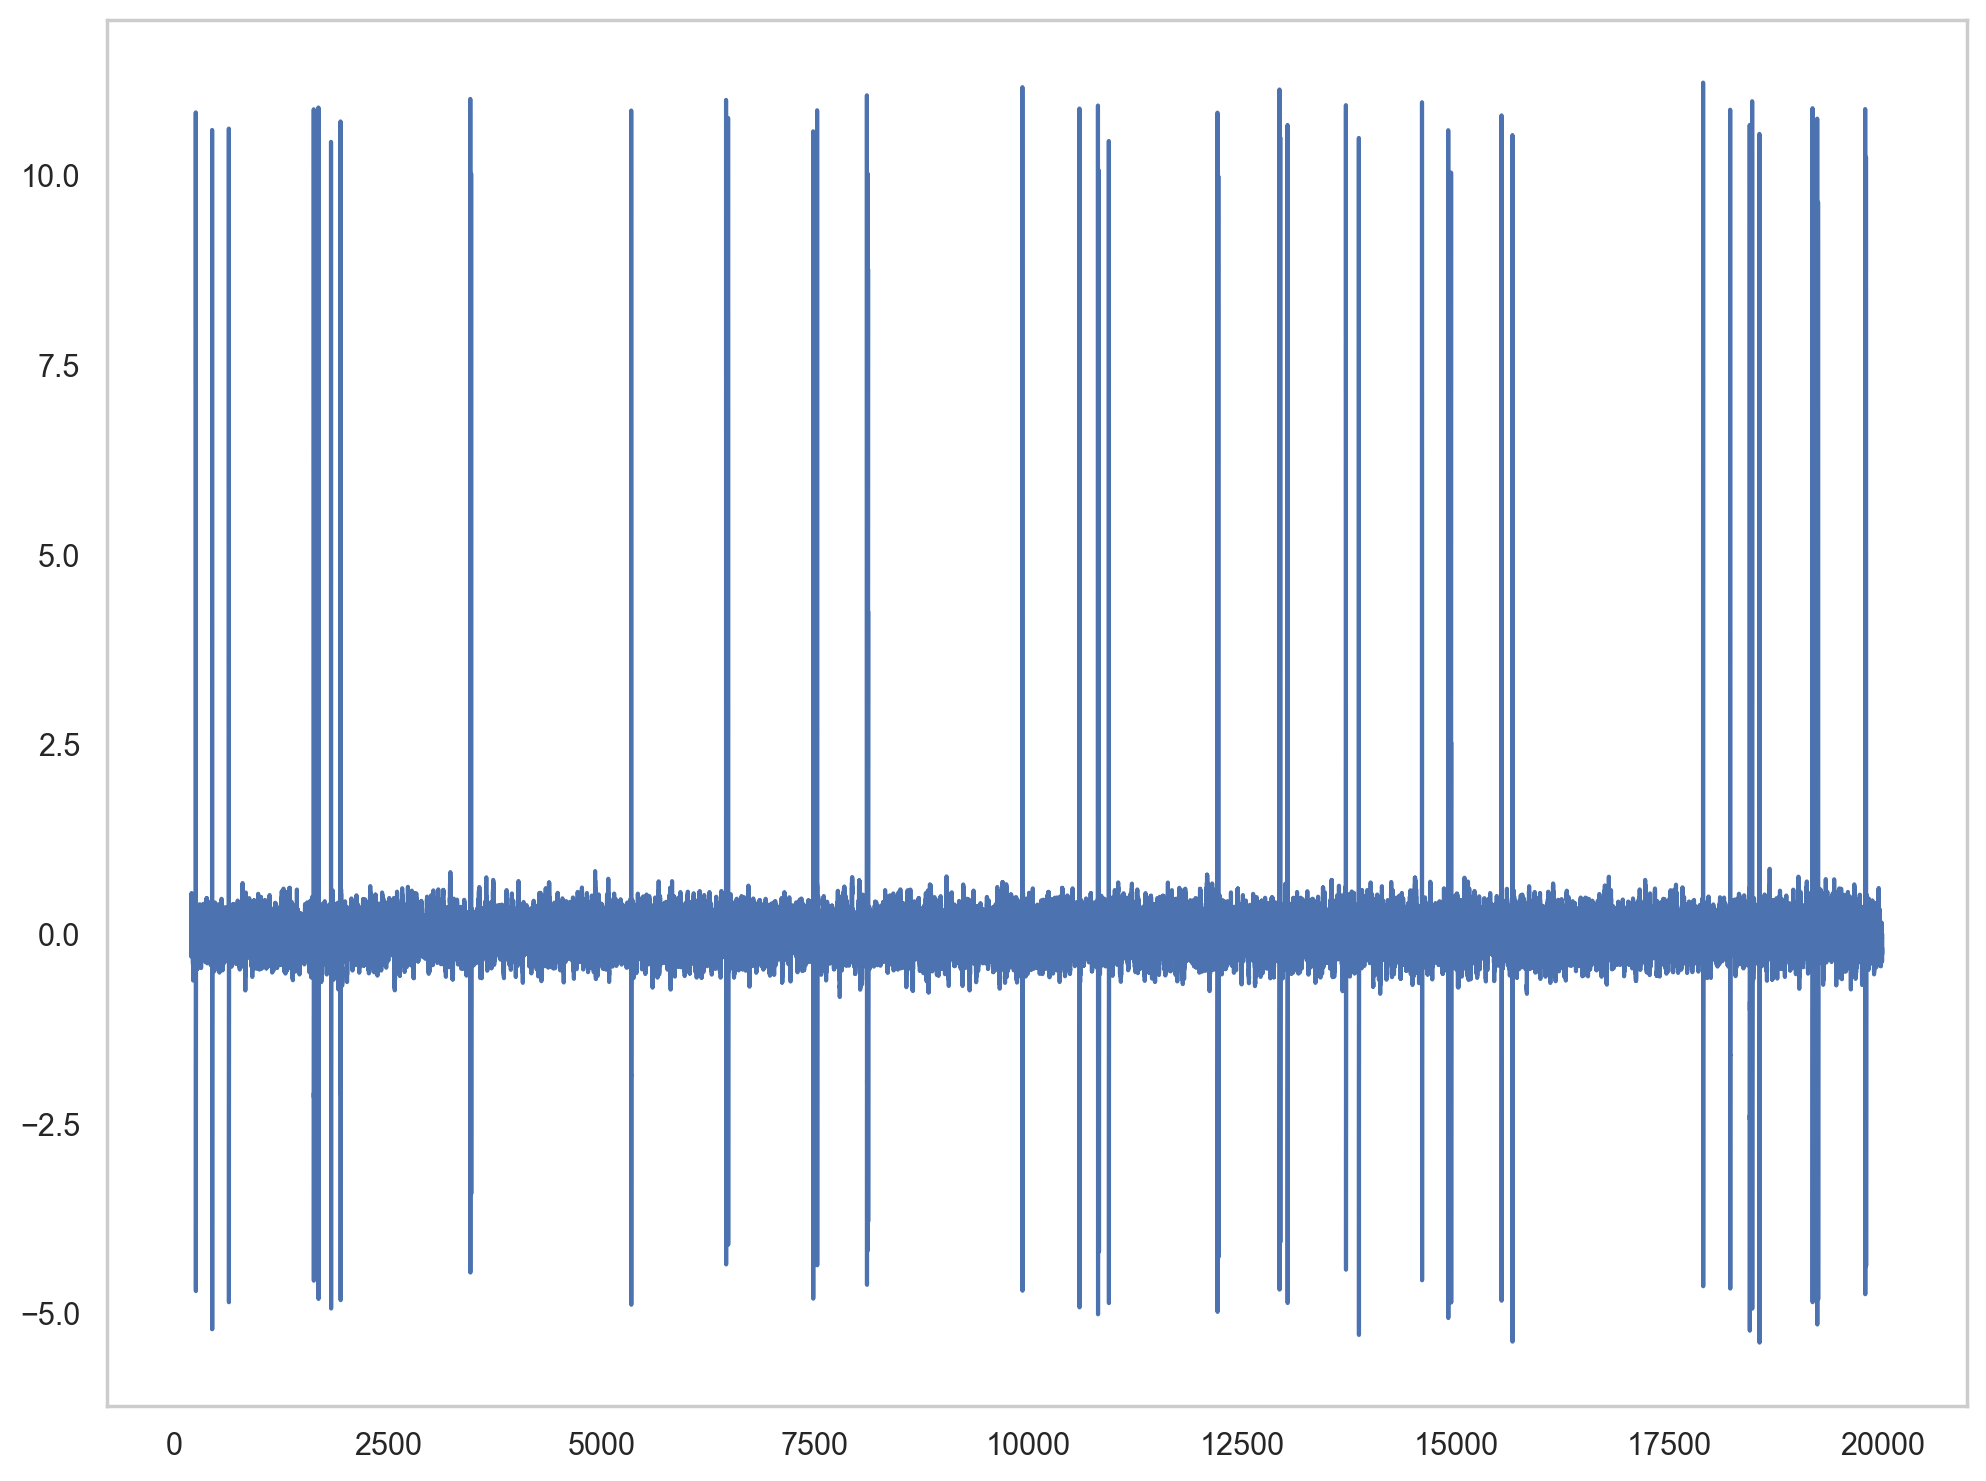

In [10]:
plt.plot(patch_times_c8[10000:1000000], patch_filt_c8[10000:1000000])

In [11]:
def compute_alt_features(stim, fs):
    return stim.mean(), stim.std()

#threshold in mVs
sp = Spike(thresh_amp=3.41, window_length=(5., 5.), smooth_frac=.01)

"""sp.alt(lfp_filt_c8, lfp_fs, compute_alt_features, queue=True,
       param_keys=['stim_mean', 'stim_std'], ref='inflection', window_length=(20, 0))"""

sp.fit(patch_filt_c8, patch_fs_c8, n_jobs=-1, progress=tqdm)

Spike:   0%|          | 0/3157 [00:00<?, ?it/s]

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [12]:
sp.df_features

,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,isi,r_squared_ramp,r_squared_exp
0,0.175373,0.34,0.345332,10.724530,0.50,1.647991,10.00000,-1.388174,94.534794,0.414519,0.088542
1,0.037657,0.36,0.395703,10.769216,0.52,1.524535,10.00000,-1.272723,191.348499,0.033234,0.108095
2,0.085917,0.38,0.285511,10.508221,0.52,1.235411,10.00000,-1.453053,195.586473,0.276448,0.054212
3,-0.095911,0.40,0.119213,10.587167,0.52,1.144384,10.00000,-1.281474,993.884734,0.269937,0.042281
4,-0.008929,0.38,0.127893,10.870652,0.52,1.355710,10.00000,-1.360448,54.813789,0.002219,0.087816
...,...,...,...,...,...,...,...,...,...,...,...
3152,0.063800,0.50,0.240056,12.354040,0.54,1.921989,10.00000,-1.366577,43.639132,0.129506,0.114553
3153,0.203912,0.52,0.427604,12.145478,0.58,1.295057,8.90097,-1.392669,147.189615,0.511270,0.234086
3154,0.047513,0.48,-0.121082,11.904458,0.54,1.572050,10.00000,-1.819343,343.315830,0.092129,0.094129
3155,0.191035,0.48,0.045890,12.221765,0.52,1.661831,10.00000,-1.470629,605.630394,0.671720,0.080978


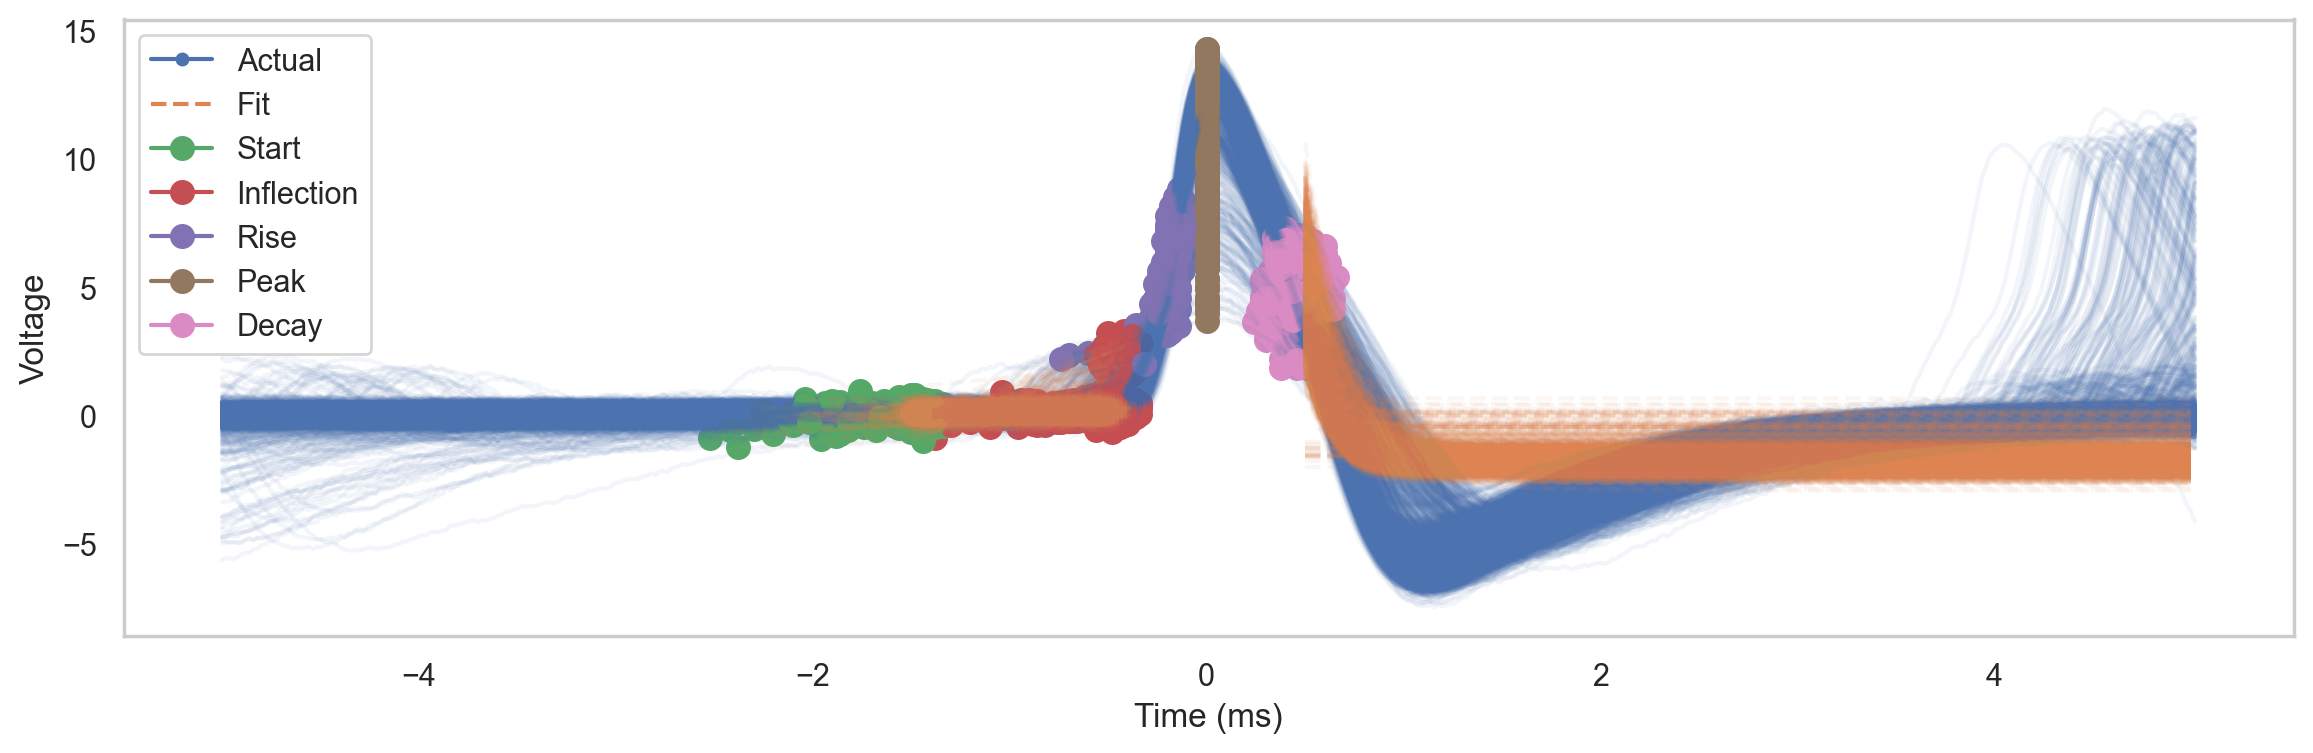

In [13]:
sp.plot(show_points=True)

#### Plot correlations 

In [14]:
df_features = sp.df_features
# Add an index column to df_features to maintain original indices
df_features['original_index'] = df_features.index



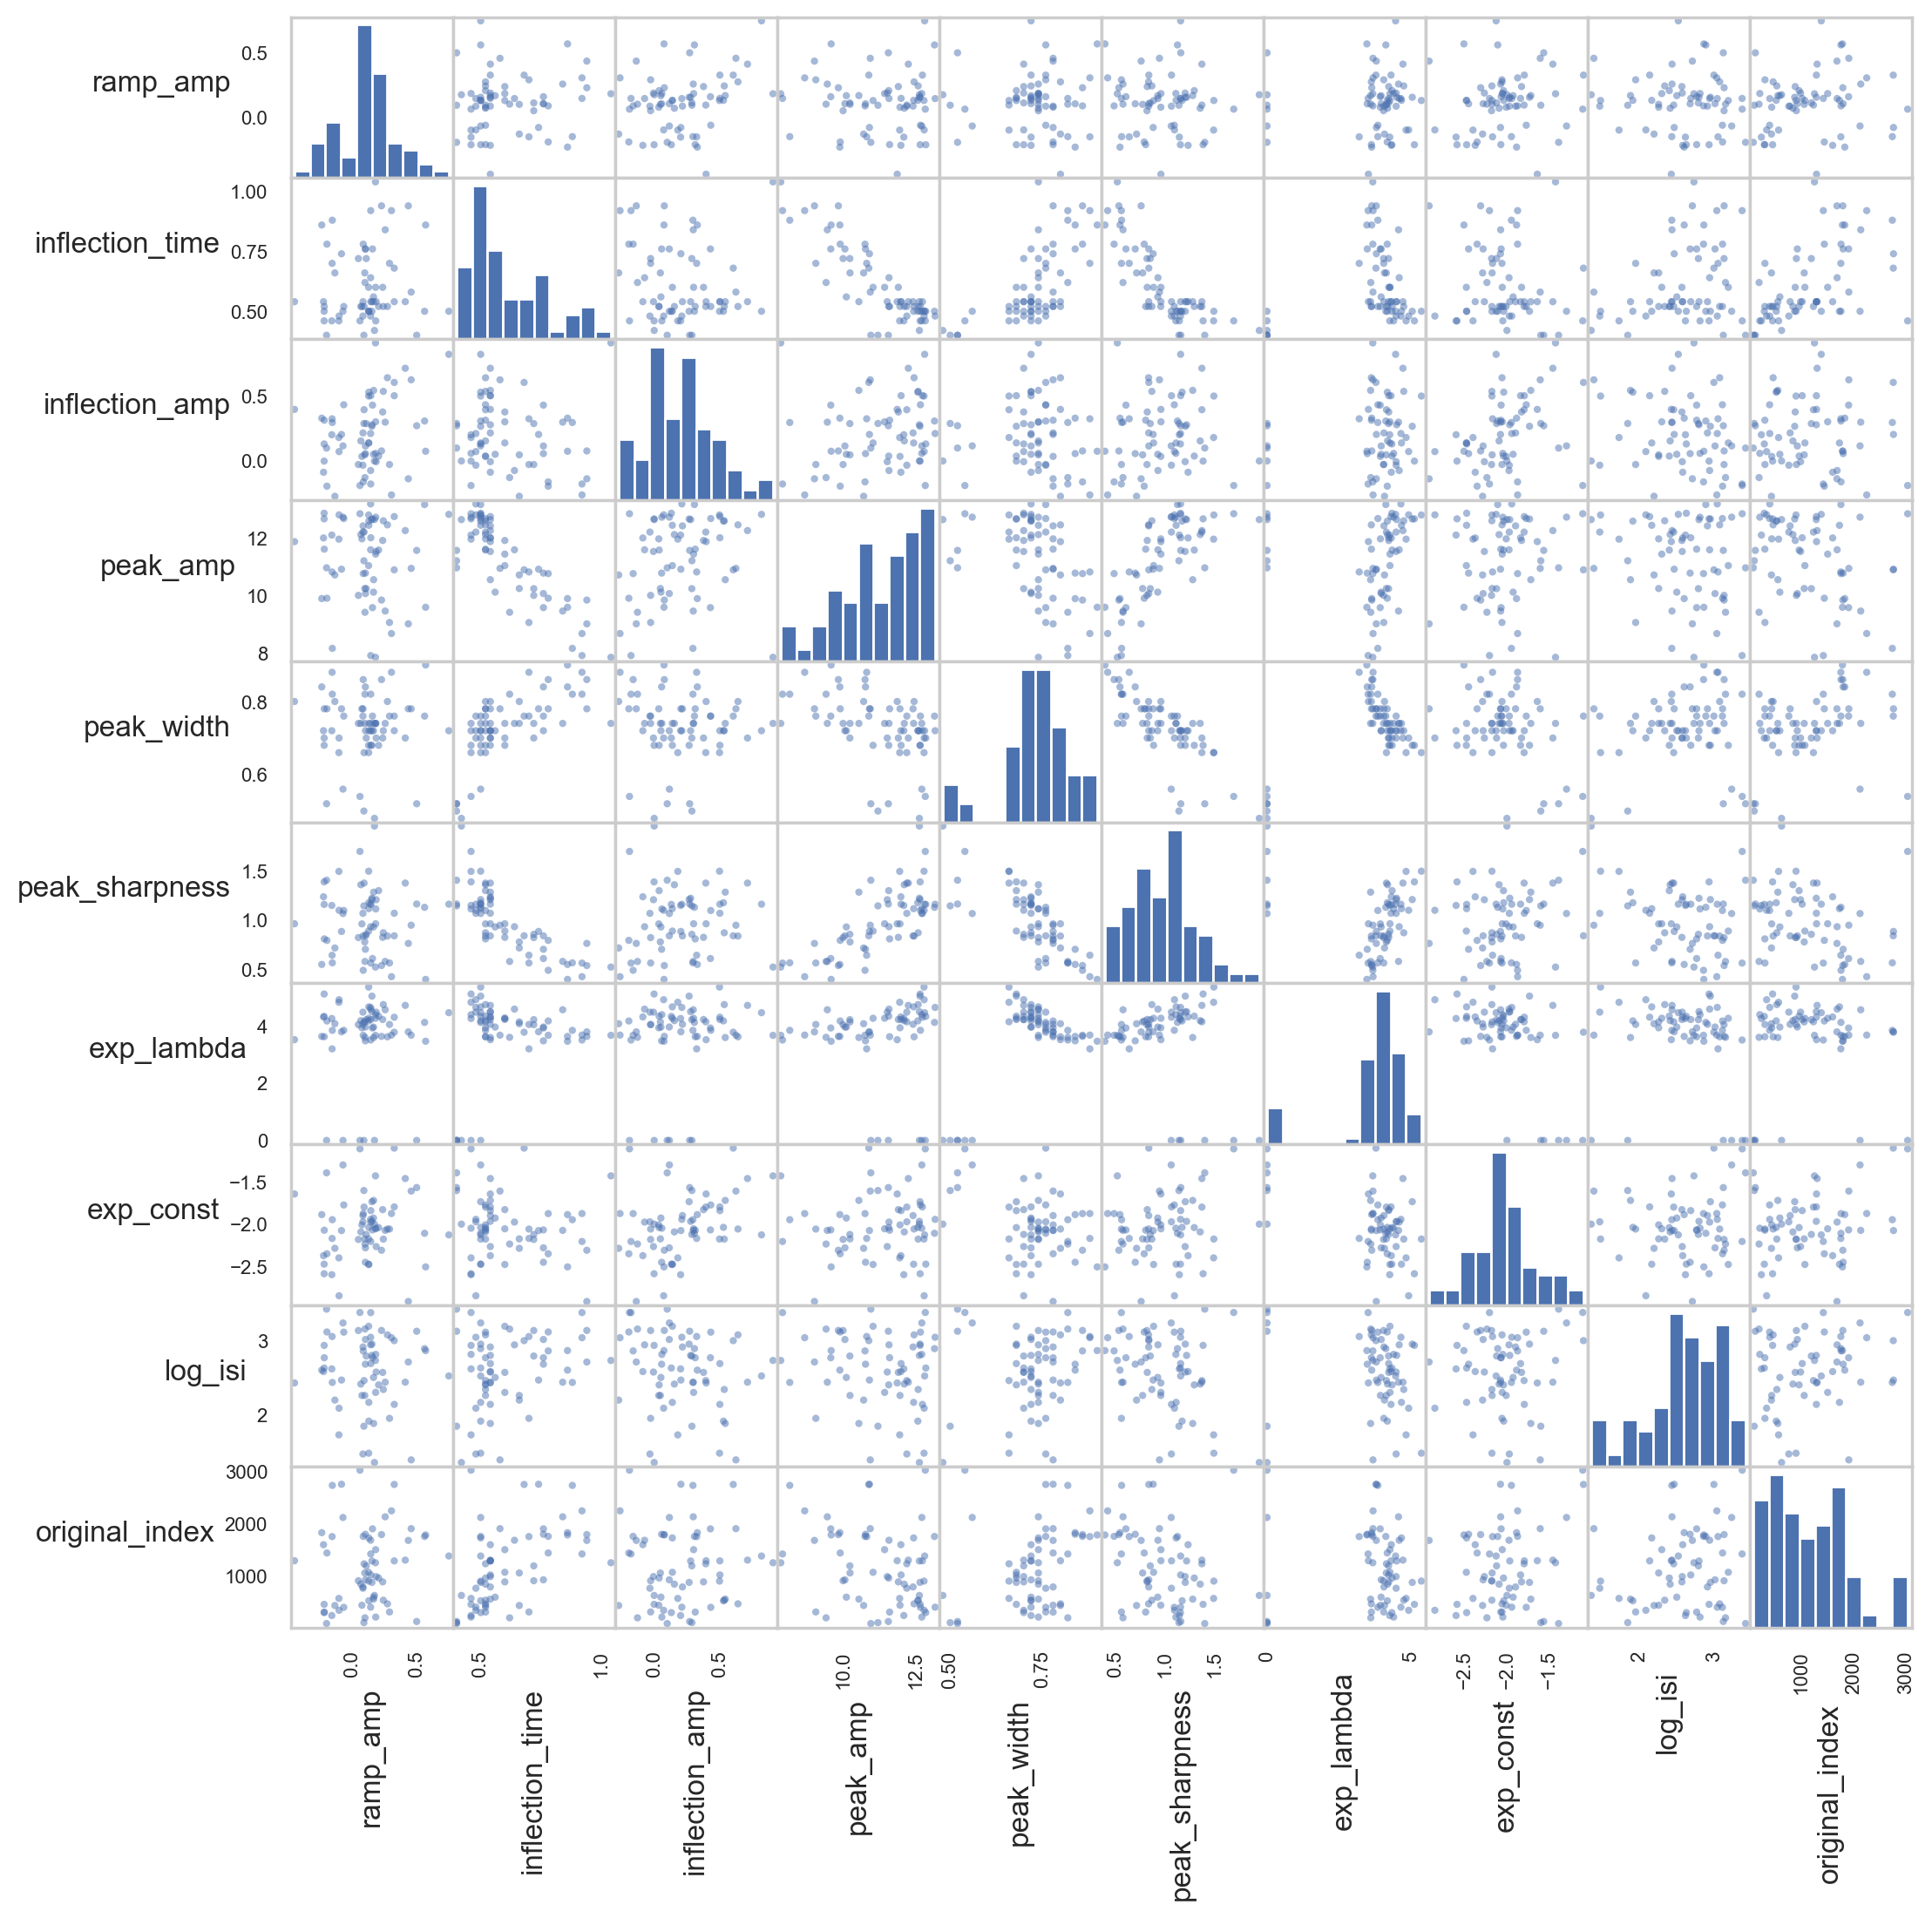

In [15]:
# Ensure inflection times are between 0 and 2 ms
df_features  = df_features .loc[df_features['inflection_time'] > 0]
df_features = df_features .loc[df_features['inflection_time'] < 2.]
#Filter based on inflection amplitude to remove weird sikes
#df_features  = df_features .loc[df_features['inflection_amp'] < 10]

# Remove low r-squares (ramping fits are especially noisy)
df_features = df_features.loc[df_features['r_squared_exp']  >= .5]
df_features = df_features.loc[df_features['r_squared_ramp'] >= .1]
# log10 ISIs
df_features[['isi']] = np.log10(df_features[['isi']])
df_features.rename(columns={'isi':'log_isi'}, inplace=True)
# drop no-longer-used QC features
df_features = df_features.drop(['r_squared_exp', 'r_squared_ramp'], axis=1)
#replace infs with NaN
df_features = df_features.replace([np.inf, -np.inf], np.nan)
# Drop rows where 'log_isi' is NaN
df_features = df_features.dropna(subset=['log_isi'])

axes = pd.plotting.scatter_matrix(df_features, alpha=0.5, figsize=(12, 12))
for ax in axes.flatten():
    ax.xaxis.label.set_rotation(90)
    ax.yaxis.label.set_rotation(0)
    ax.yaxis.label.set_ha('right')
plt.show()

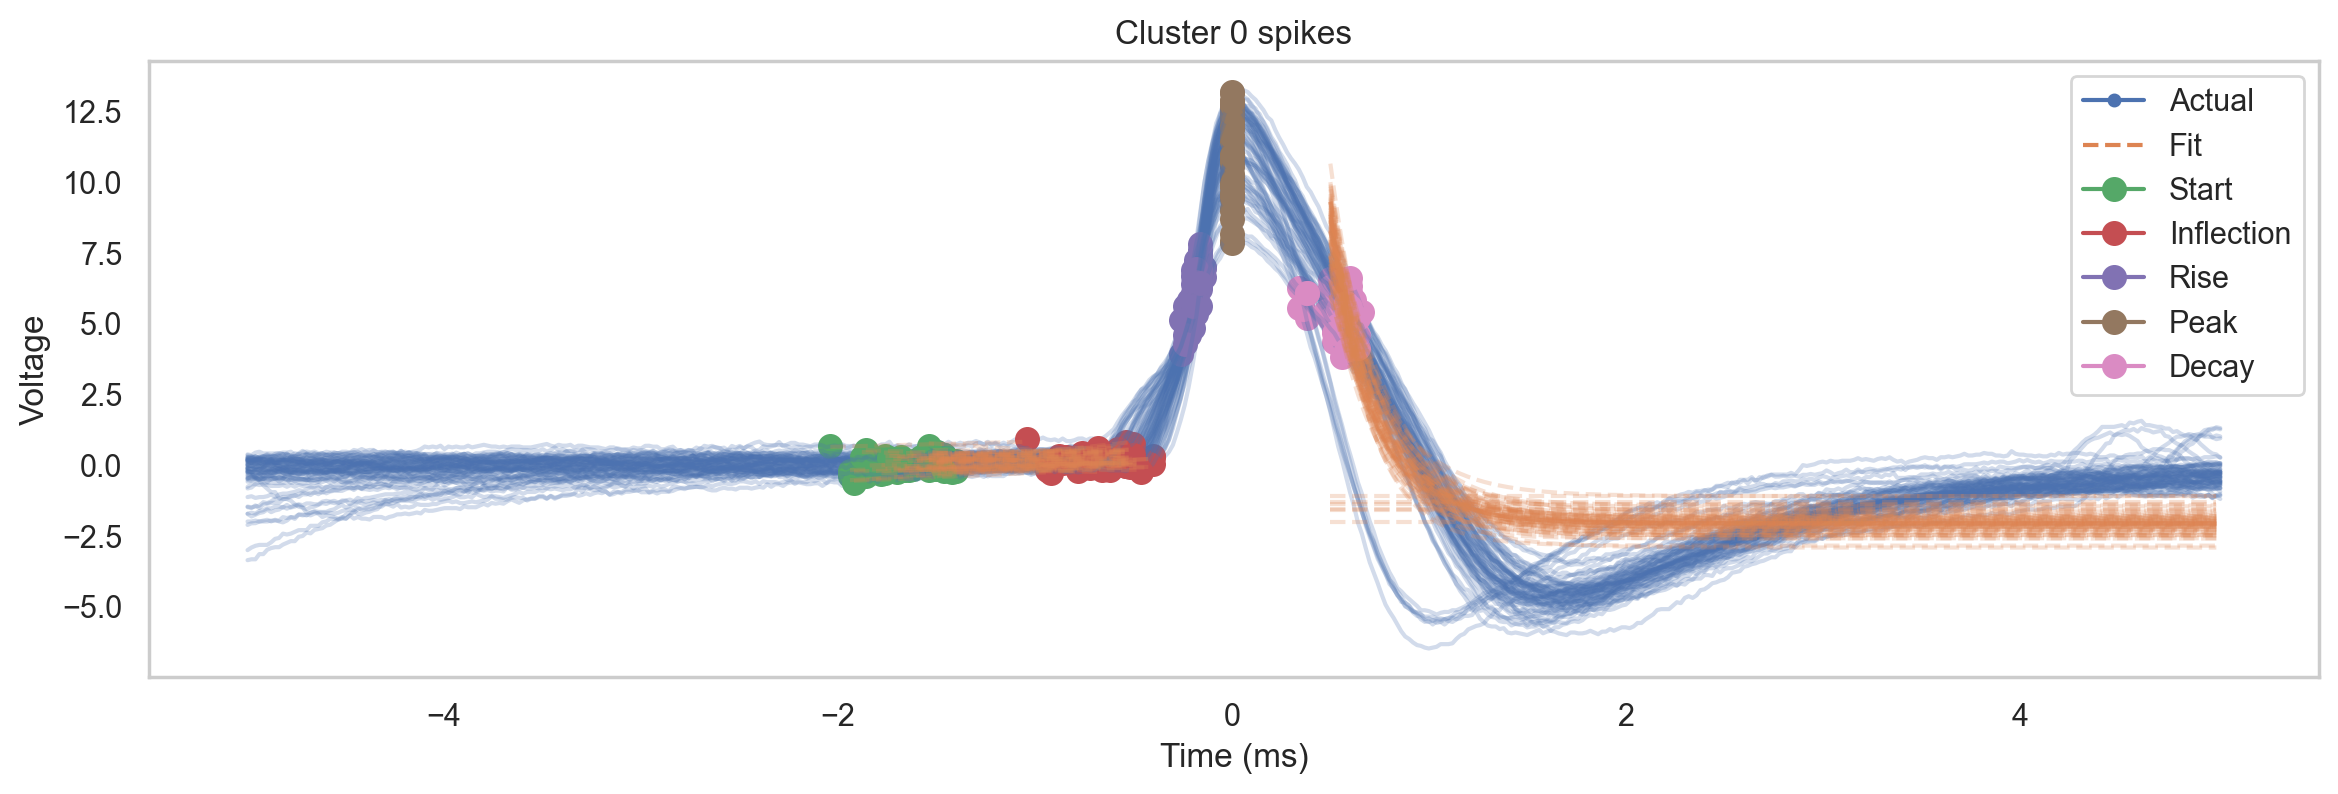

In [16]:
filtered_indices = df_features['original_index'].values
sp.plot(inds=filtered_indices, mode='full', show_points=True)
plt.title("Cluster 0 spikes")
plt.show()

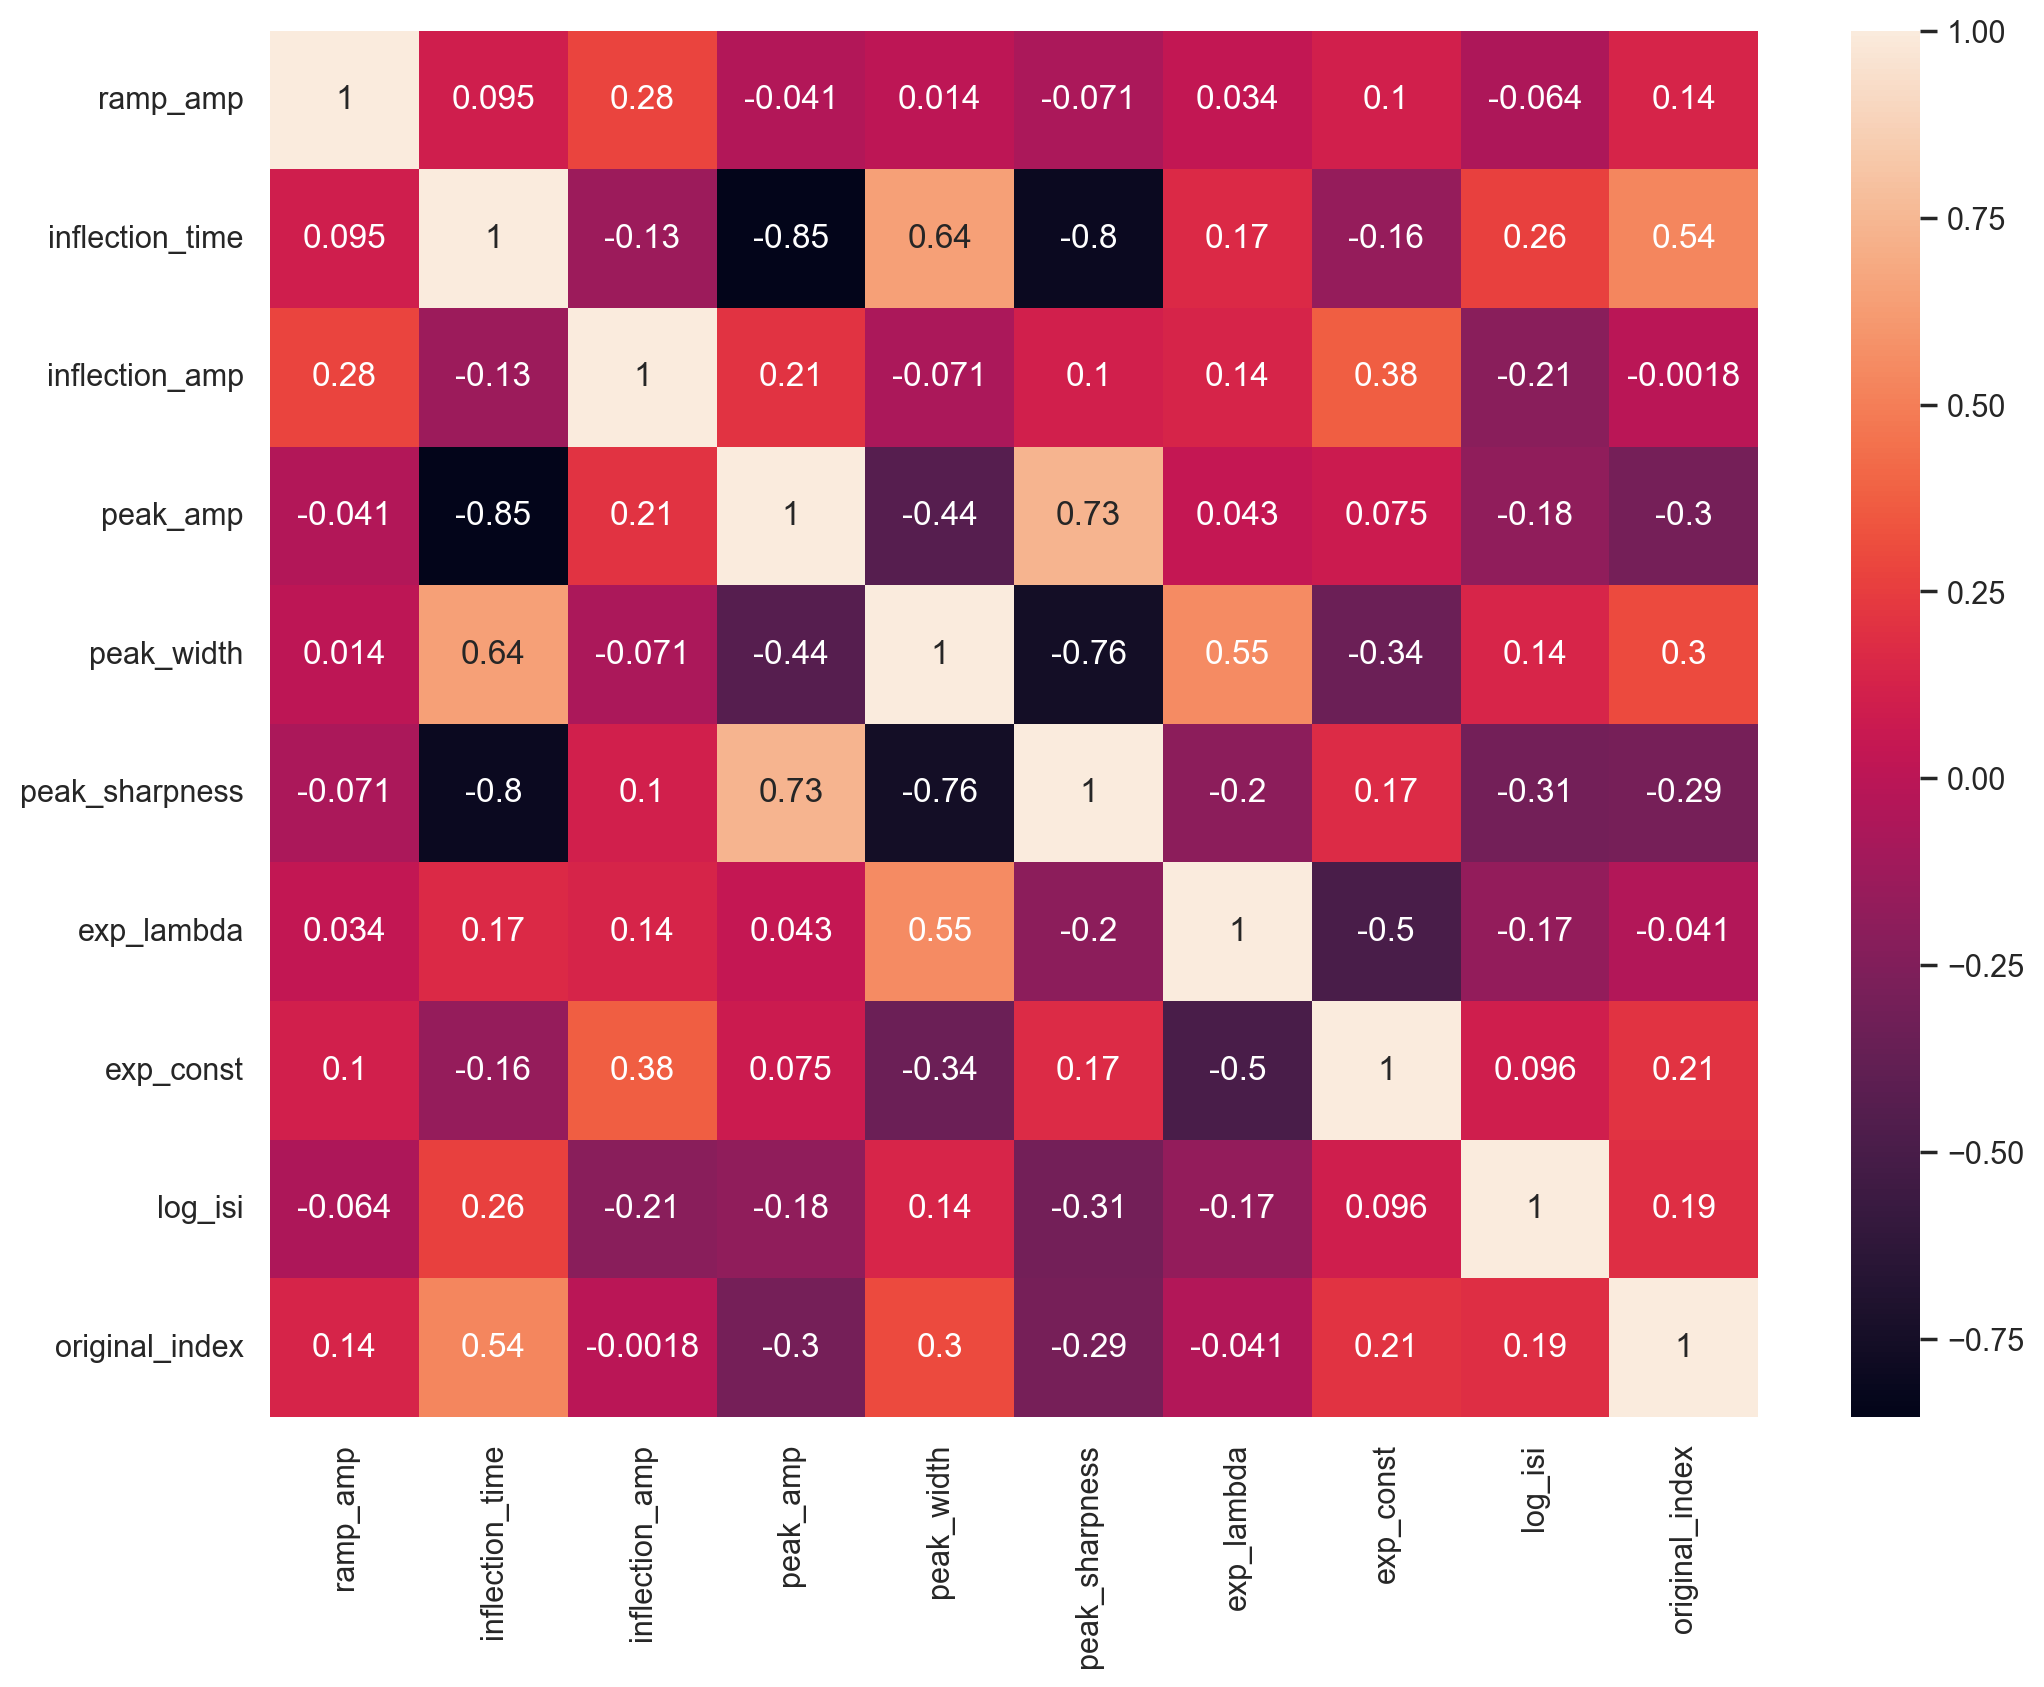

,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,log_isi,original_index
ramp_amp,1.0***,0.1,0.28*,-0.04,0.01,-0.07,0.03,0.1,-0.06,0.14
inflection_time,0.1,1.0***,-0.13,-0.85***,0.64***,-0.8***,0.17,-0.16,0.26*,0.54***
inflection_amp,0.28*,-0.13,1.0***,0.21,-0.07,0.1,0.14,0.38**,-0.21,-0.0
peak_amp,-0.04,-0.85***,0.21,1.0***,-0.44***,0.73***,0.04,0.07,-0.18,-0.3*
peak_width,0.01,0.64***,-0.07,-0.44***,1.0***,-0.76***,0.55***,-0.34**,0.14,0.3*
peak_sharpness,-0.07,-0.8***,0.1,0.73***,-0.76***,1.0***,-0.2,0.17,-0.31*,-0.29*
exp_lambda,0.03,0.17,0.14,0.04,0.55***,-0.2,1.0***,-0.5***,-0.17,-0.04
exp_const,0.1,-0.16,0.38**,0.07,-0.34**,0.17,-0.5***,1.0***,0.1,0.21
log_isi,-0.06,0.26*,-0.21,-0.18,0.14,-0.31*,-0.17,0.1,1.0***,0.19
original_index,0.14,0.54***,-0.0,-0.3*,0.3*,-0.29*,-0.04,0.21,0.19,1.0***


In [17]:
#df_features_correlation = df_features.corr()
# Plot the heatmap and annotation on it
sns.heatmap(df_features.corr(), xticklabels=df_features.corr().columns,
            yticklabels=df_features.corr().columns, annot=True)
plt.show()
rho = df_features.corr()
pval = df_features.corr(method=lambda x, y: pearsonr(x, y)[1]) - np.eye(*rho.shape)
p = pval.map(lambda x: ''.join(['*' for t in [0.001,0.01,0.05] if x<=t]))
rho.round(2).astype(str) + p

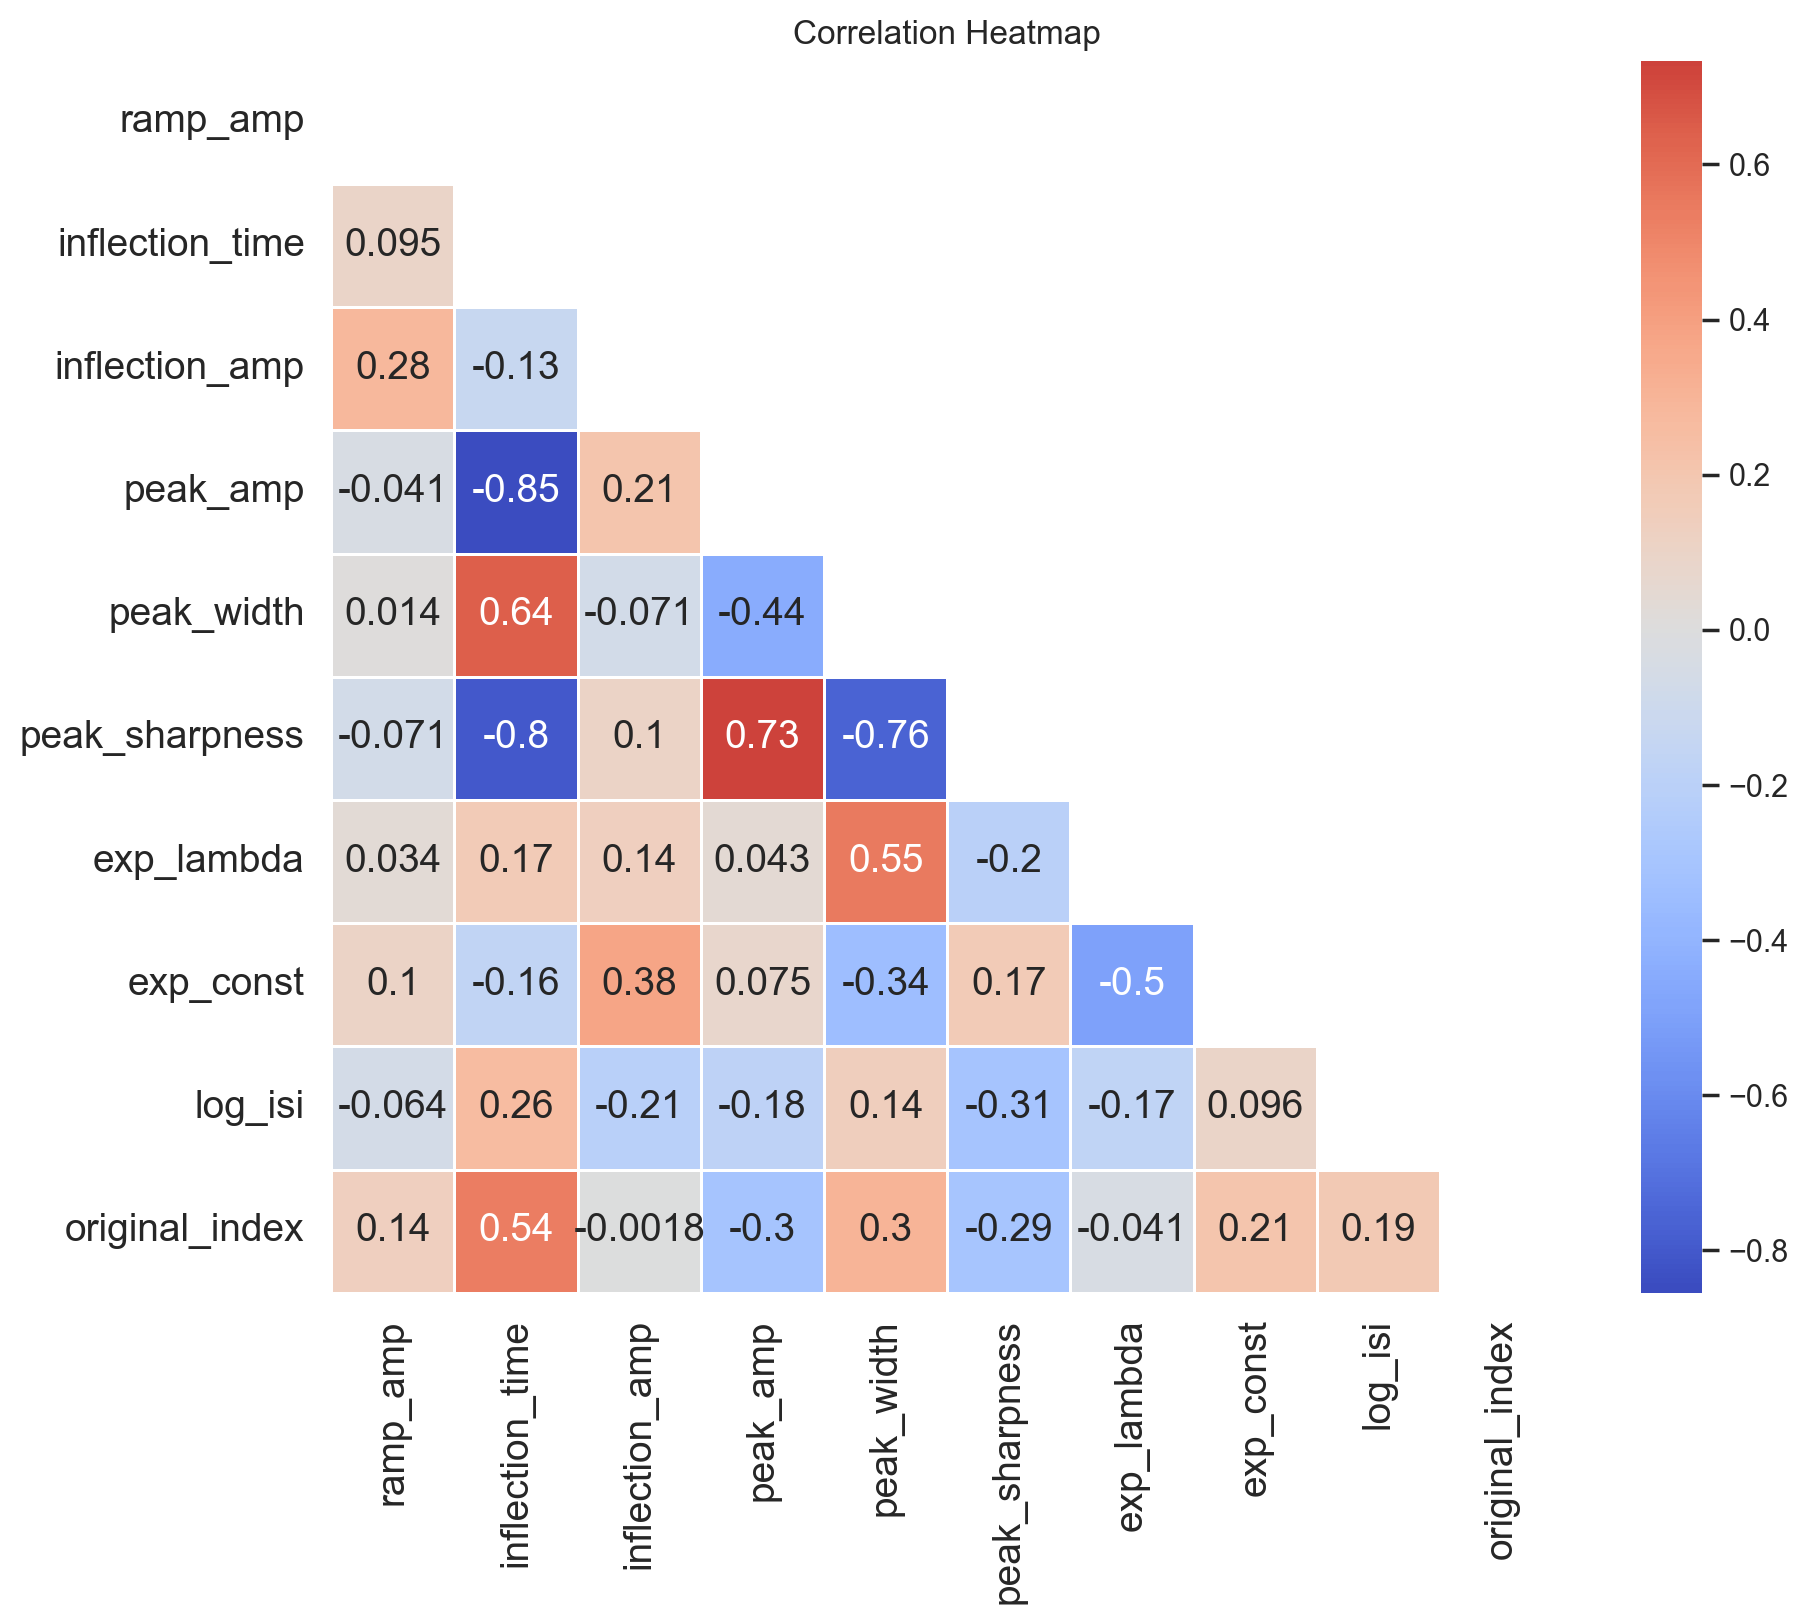

In [18]:
# Calculate correlation matrix and p-values
rho = df_features.corr()
pval = df_features.corr(method=lambda x, y: pearsonr(x, y)[1]) - np.eye(*rho.shape)
p = pval < 0.05  # Create a mask for significant p-values

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(rho, dtype=bool))

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(rho, mask=mask, cmap='coolwarm', annot=True, fmt='.2', linewidths=0.5, center=0, square=True,  annot_kws={"size": 14})
# Increase fontsize of tick labels on both axes
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.title('Correlation Heatmap')
plt.show()


## Linear regression model to predict time of next spike (isi) based on inflection features 

(array([ 4.,  1.,  4.,  3.,  5., 13., 11.,  9., 12.,  4.]),
 array([1.35313147, 1.55996091, 1.76679036, 1.9736198 , 2.18044925,
        2.38727869, 2.59410813, 2.80093758, 3.00776702, 3.21459647,
        3.42142591]),
 <BarContainer object of 10 artists>)

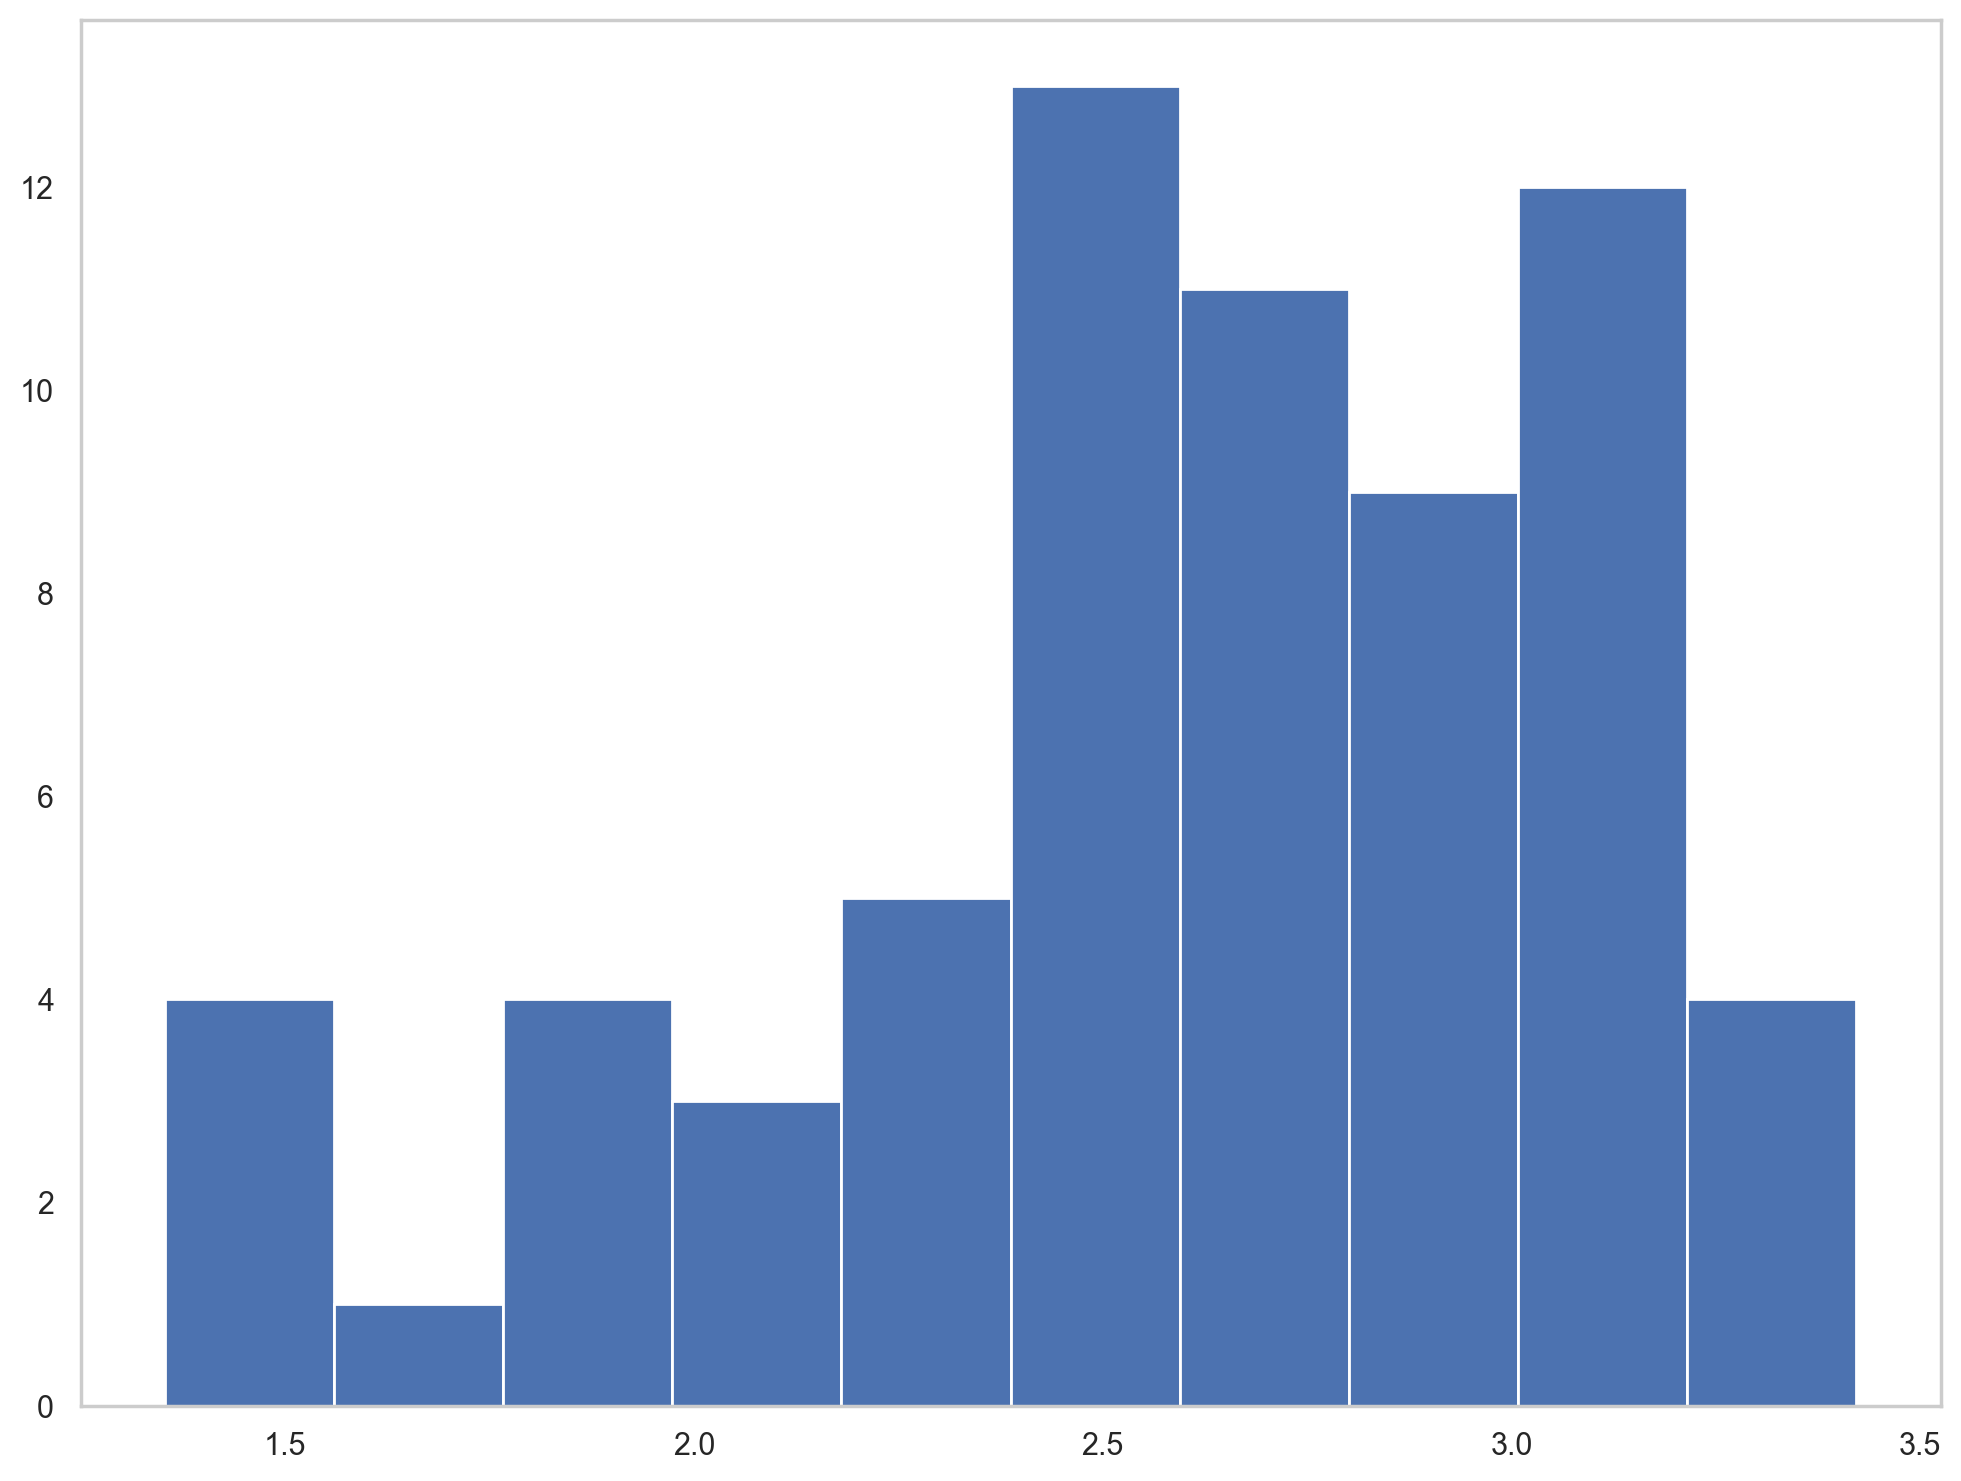

In [22]:
plt.hist(df_features['log_isi'])


### Run regression without splitting into clusters 

In [20]:
# Standardize features
scaler = StandardScaler()
features = df_features.drop(columns=['log_isi']).values
target = df_features['log_isi'].values

features_scaled = scaler.fit_transform(features)

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(features_scaled, target, test_size=0.2, random_state=42)


# Function to train the model with progress tracking
def train_model_with_progress(X_train, y_train, max_iter=1000):
    model = Ridge(solver='saga', max_iter=1, random_state=42)
    progress_bar = tqdm(range(max_iter), desc="Training Ridge Regression")
    for _ in progress_bar:
        model.max_iter += 1
        model.fit(X_train, y_train)
    return model

In [21]:
# Train model with progress tracking
start_time = time.time()
model = train_model_with_progress(X_train, y_train)
print("Training time for the model:", time.time() - start_time)

# Predict and calculate mean squared error and R-squared
predictions = model.predict(X_test)
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)
print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')

Training Ridge Regression:   0%|          | 0/1000 [00:00<?, ?it/s]

Training time for the model: 0.9164049625396729
Mean Squared Error: 0.44591668411304386
R-squared: -1.0671585916301223


In [ ]:
# Visualization of predictions
plt.figure(figsize=(10, 6))
plt.scatter(y_test, predictions, alpha=0.6)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')  # 45-degree line
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values')
plt.show()

# Visualization of residuals
residuals = y_test - predictions
plt.figure(figsize=(10, 6))
plt.scatter(predictions, residuals, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs. Predicted Values')
plt.show()

# Feature importance
feature_importance = model.coef_

actual_feature_names = ['ramp_amp', 'inflection_time', 	'inflection_amp', 	'peak_amp ',	'peak_width', 	'peak_sharpness', 	'exp_lambda', 	'exp_const', 'indices']  # replace with your actual feature names

plt.figure(figsize=(10, 6))
plt.barh(np.arange(len(feature_importance)), feature_importance)
plt.yticks(np.arange(len(feature_importance)), actual_feature_names )  # Replace with actual feature names
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Feature Importance in Ridge Regression Model')
plt.show()
